# Fit PACE v3_1 data with various RT choices

In [34]:
# imports
from importlib import reload
import os, sys
import numpy as np

from matplotlib import pyplot as plt

import xarray
import pandas

from ocpy.pace import io as pace_io
from ocpy.utils import plotting

from bing.parameters import standard
from bing.models import utils as model_utils
from bing.priors import priors as bing_priors
from bing.fitting import inference as bing_inf
from bing import evaluate
from bing.fitting import chisq_fit
from bing import plotting as bing_plotting
from bing import evaluate

#
# Locals
sys.path.append(os.path.abspath("../../py"))
from grab_pace_granules import closest_Rrs
import biomass_io
import fitting

In [9]:
match_file = '../../matched_argo_bgc_profiles_bbp_v2.csv'
# Load up Argo profiles, already matched to PACE
matched = pandas.read_csv(match_file)

# Load up one spectrum

In [11]:
imatched = matched.iloc[0]
imatched.closest_file = 'PACE_OCI.20250601T070425.L2.OC_AOP.V3_1.nc'
gfile = os.path.join(biomass_io.PACE_L2_AOP_PATH, imatched.closest_file)
print(f"----- Loading {gfile} -----")
xds, flags = pace_io.load_oci_l2(gfile)

----- Loading /home/xavier/Projects/Oceanography/data/Color/PACE/L2_AOP_V3_1/PACE_OCI.20250601T070425.L2.OC_AOP.V3_1.nc -----


## Closest pixel 

In [16]:
nclosest=2
d_min, dmin_ij = closest_Rrs(xds, (imatched.lat, imatched.lon),
                                 nclosest=nclosest)

In [17]:
gd_wave = (xds.wavelength.data >= 400.) &  (xds.wavelength.data <= 700.) 

In [18]:
# Setup
items = []
for ss in range(nclosest):
    ix, iy = dmin_ij[0][ss], dmin_ij[1][ss]
    iwave = xds.wavelength.data[gd_wave]
    ispec = xds.Rrs.data[ix,iy,gd_wave]
    isig = xds.Rrs_unc.data[ix,iy,gd_wave]
    items.append((iwave, ispec, isig))

# Plot the first one

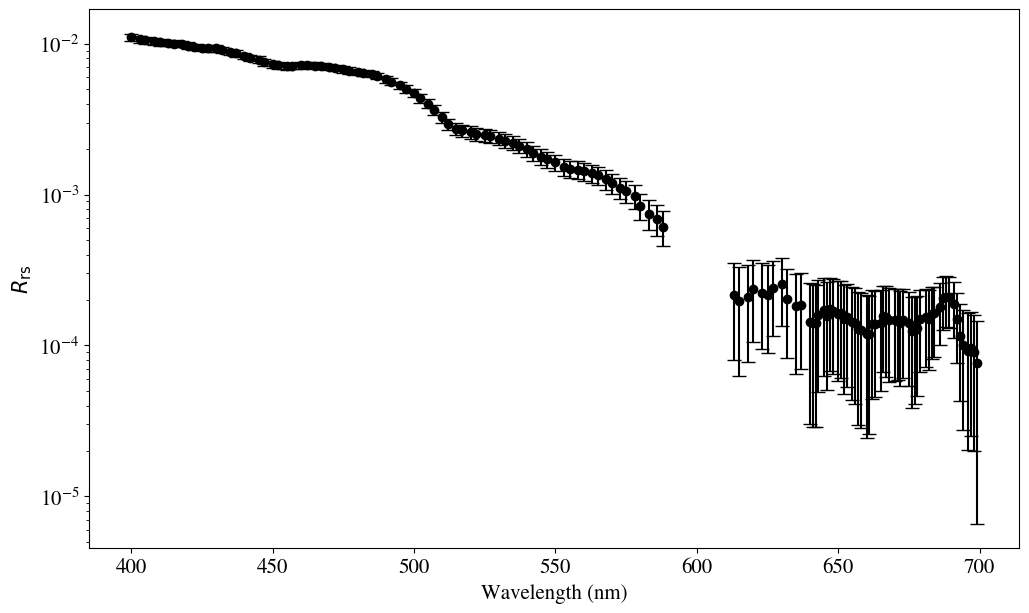

In [20]:
fig = plt.figure(figsize=(12,7))
ax = plt.gca()
#
ax.errorbar(items[0][0], items[0][1], yerr=items[0][2],
                color='k',  fmt='o', capsize=5) 
#
ax.set_yscale('log')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel(r'$R_{\rm rs}$')
#
plotting.set_fontsize(ax, 15.)
#
plt.show()

# Fit it, plain vanilla

In [45]:
p_V = standard.expb_pow(satellite='PACE', add_noise=False,  variable_Gordon=False)

In [46]:
models_V, ans_V, rt_dict_V = fitting.fit_me(items[0], in_p=p_V, return_early=True)

In [25]:
ans_V

array([-1.80727172,  0.01777452, -2.06150607, -3.01960187,  1.94436984])

## Plot me

In [31]:
def plot(models, ans, rt_dict, items):
    _, ispec, isig = items
    Chl = 10**ans[2] / 0.05582
    _ = bing_plotting.show_fits(models, ans, rt_dict, Chl, None,
                figsize=(12,4), fontsize=13., show=True,
                Rrs_true=dict(wave=models[0].wave, spec=ispec, var=isig**2),
                log_abb=True )

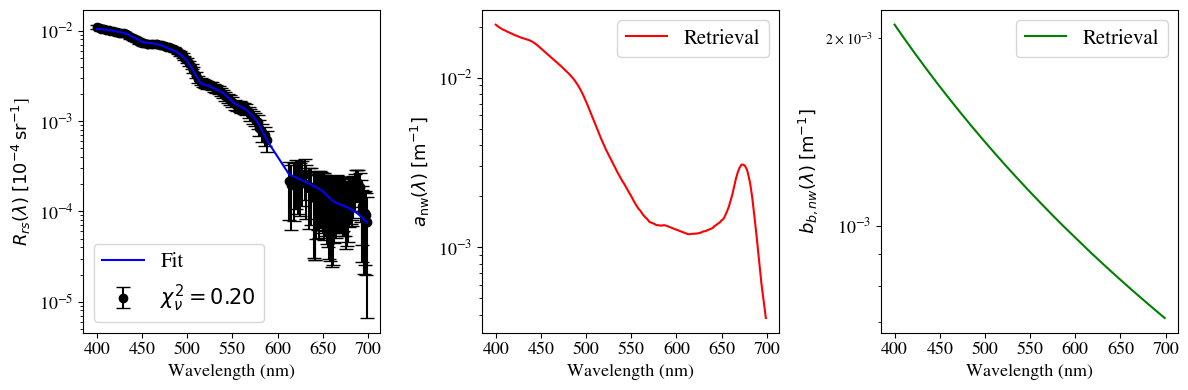

In [32]:
plot(models_V, ans_V, rt_dict_V, items[0])

# Variable Gordon

### Just re-generate the models

In [38]:
models_V[0].G1 = None
models_V[0].G2 = None
Chl = 10**ans_V[2] / 0.05582
model_Rrs_V, _, _ = evaluate.reconstruct_chisq_fits(models_V, ans_V, rt_dict_V, Chl=Chl)

In [41]:
models_V[0].init_var_gordon()
model_Rrs_GV, _, _ = evaluate.reconstruct_chisq_fits(models_V, ans_V, rt_dict_GV, Chl=Chl)

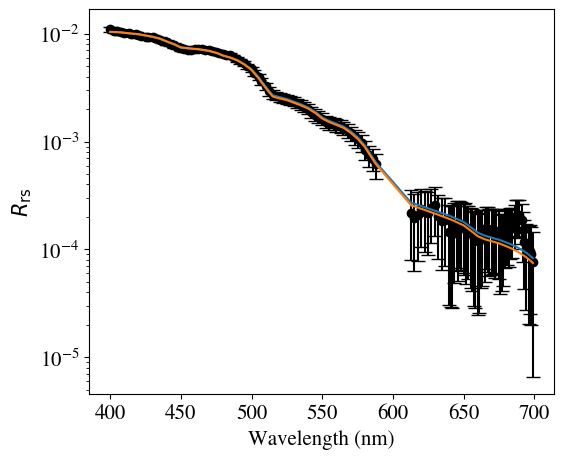

In [54]:
fig = plt.figure(figsize=(6,5))
ax = plt.gca()
#
ax.errorbar(items[0][0], items[0][1], yerr=items[0][2],
                color='k',  fmt='o', capsize=5, label='Data', zorder=1) 
ax.plot(models_V[0].wave, model_Rrs_V, label='Vanilla',zorder=10)
ax.plot(models_V[0].wave, model_Rrs_GV, label='Gordon',zorder=20)
#
ax.set_yscale('log')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel(r'$R_{\rm rs}$')
#
plotting.set_fontsize(ax, 15.)
#
plt.show()

## Now actual fit

In [47]:
p_G = standard.expb_pow(satellite='PACE', add_noise=False,  variable_Gordon=True)

In [58]:
models_G, ans_G, rt_dict_G = fitting.fit_me(items[0], in_p=p_G, return_early=True)
ans_G

array([-1.82331843,  0.01810036, -2.02729039, -2.984477  ,  1.71222213])

## Start with a better guess

In [57]:
reload(fitting)
models_G, ans_G, rt_dict_G = fitting.fit_me(items[0], in_p=p_G, return_early=True, guess_vals=ans_V)
ans_G

array([-1.82329296,  0.01810037, -2.02725975, -2.9844926 ,  1.71266205])

In [56]:
ans_V

array([-1.80727172,  0.01777452, -2.06150607, -3.01960187,  1.94436984])

# Now Raman

In [63]:
p_R = standard.expb_pow(satellite='PACE', add_noise=False,  variable_Gordon=True, include_Raman=True)

In [60]:
reload(fitting)
models_R, ans_R, rt_dict_R = fitting.fit_me(items[0], in_p=p_R, return_early=True)
ans_R

array([-1.79723247,  0.01702499, -2.07497261, -3.06414429,  1.06416874])

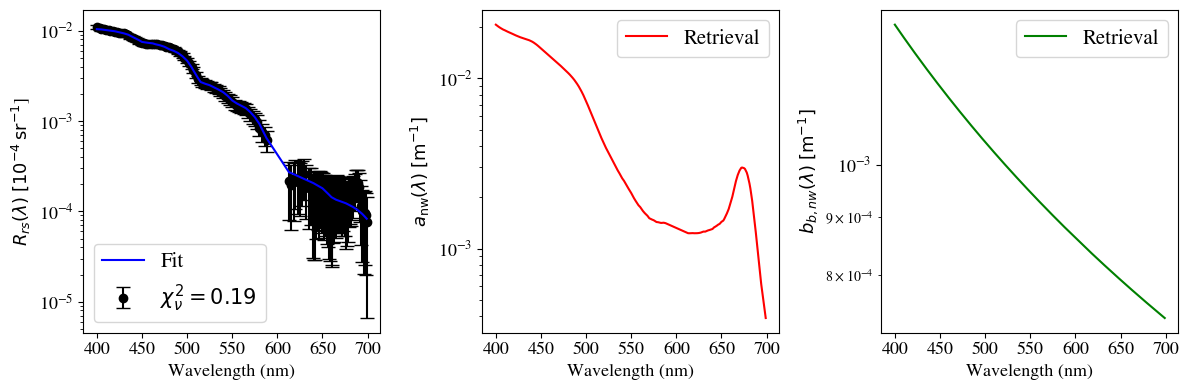

In [61]:
plot(models_R, ans_R, rt_dict_R, items[0])

# Now Chl

In [64]:
p_C = standard.expb_pow(satellite='PACE', add_noise=False,  variable_Gordon=True, include_Raman=True,
                        include_Chl_fl=True, phi_C=0.02, double_gaussian=True)

In [67]:
reload(fitting)
models_C, ans_C, rt_dict_C = fitting.fit_me(items[0], in_p=p_C, return_early=True)
ans_C

array([-1.67067432,  0.01119864, -2.36593958, -3.08254309,  2.        ])

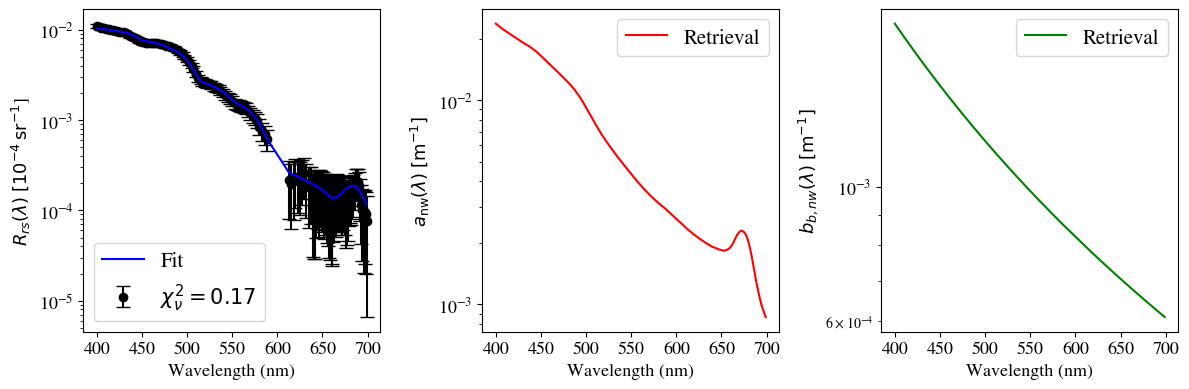

In [66]:
plot(models_C, ans_C, rt_dict_C, items[0])